In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

In [2]:
# =========================================================
# 1️⃣ DATA PATHS
# =========================================================
data_dir = r"C:/Users/profr/Saksham/dataset"

# =========================================================
# 2️⃣ IMAGE GENERATOR
# =========================================================
img_height = 150
img_width = 150
batch_size = 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [3]:
train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',     # Softmax → categorical labels
    subset='training'
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False                 # Required for ROC & CM
)
# Class indices
print("Class Mapping:", train_gen.class_indices)

Found 3506 images belonging to 2 classes.
Found 876 images belonging to 2 classes.
Class Mapping: {'crowded': 0, 'not_crowded': 1}


In [4]:
# =========================================================
# 3️⃣ BUILD CNN MODEL (Softmax Output)
# =========================================================
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(img_height, img_width, 3)),
    MaxPooling2D(2,2),
    
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    #Conv2D(128, (3,3), activation='relu'),
    #MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(2, activation='softmax')     # Softmax classifier
])

C:\Users\profr\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 74, 74, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 72, 72, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 36, 36, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 82944)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      10,616,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │             258 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,636,610 (40.58 MB)

 Trainable params: 10,636,610 (40.58 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# =========================================================
# 4️⃣ TRAIN MODEL
# =========================================================
history = model.fit(
    train_gen,
    epochs=20,
    validation_data=val_gen
)


C:\Users\profr\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 226s 1s/step - accuracy: 0.6828 - loss: 0.8850 - val_accuracy: 0.7808 - val_loss: 0.6034
Epoch 2/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 197s 894ms/step - accuracy: 0.9100 - loss: 0.2458 - val_accuracy: 0.7454 - val_loss: 0.6628
Epoch 3/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 229s 1s/step - accuracy: 0.9677 - loss: 0.0939 - val_accuracy: 0.7614 - val_loss: 0.9356
Epoch 4/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 207s 942ms/step - accuracy: 0.9771 - loss: 0.0588 - val_accuracy: 0.7728 - val_loss: 0.9914
Epoch 5/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 205s 935ms/step - accuracy: 0.9854 - loss: 0.0445 - val_accuracy: 0.7580 - val_loss: 1.1027
Epoch 6/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 205s 927ms/step - accuracy: 0.9852 - loss: 0.0396 - val_accuracy: 0.7683 - val_loss: 1.0208
Epoch 7/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 185s 843ms/step - accuracy: 0.9974 - loss: 0.0127 - val_accuracy: 0.7648 - val_loss: 1.0392
Epoch 8/20
220/220 ━━━━━━━━━━━━━━━━━━━━ 191s 869ms/step - accuracy: 0.9969 - loss:

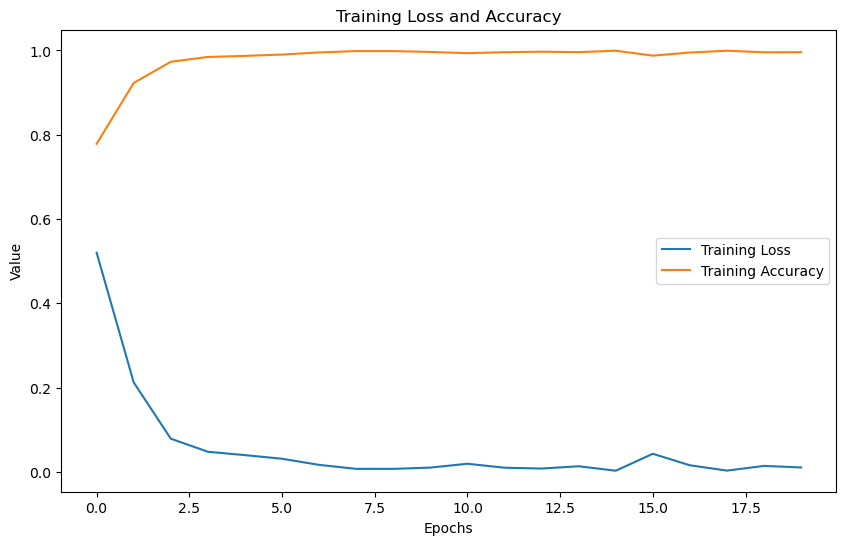

In [11]:
import matplotlib.pyplot as plt

# =========================================================
# Combined Plot for LOSS & ACCURACY (Training Only)
# =========================================================

plt.figure(figsize=(10,6))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['accuracy'], label='Training Accuracy')
#plt.plot(history.history['val_loss'], label='Validation Loss')
#plt.plot(history.history['val_accuracy'], label='Validation Accuracy')


plt.title("Training Loss and Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Value")
plt.legend()

# Save with 600 DPI
#plt.savefig("CNN2_Train_Loss_Accuracy.png", dpi=600)

plt.show()


In [8]:
# =========================================================
# 6️⃣ CONFUSION MATRIX & REPORT
# =========================================================
# Predict labels
y_pred_proba = model.predict(val_gen)
y_pred = np.argmax(y_pred_proba, axis=1)

y_true = val_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Classification Summary Report
report = classification_report(y_true, y_pred, target_names=list(train_gen.class_indices.keys()))
print("\n=== Classification Report ===")
print(report)

55/55 ━━━━━━━━━━━━━━━━━━━━ 49s 903ms/step

=== Confusion Matrix ===
[[369 159]
 [ 92 256]]

=== Classification Report ===
              precision    recall  f1-score   support

     crowded       0.80      0.70      0.75       528
 not_crowded       0.62      0.74      0.67       348

    accuracy                           0.71       876
   macro avg       0.71      0.72      0.71       876
weighted avg       0.73      0.71      0.72       876



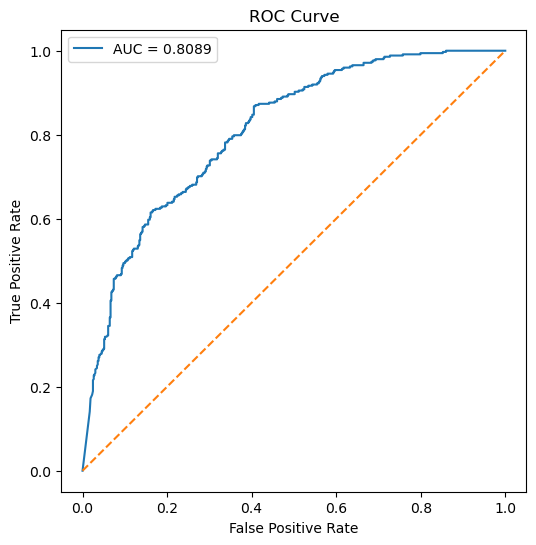

In [12]:
# =========================================================
# 7️⃣ AUC–ROC CURVE
# =========================================================
y_true_bin = to_categorical(y_true, num_classes=2)

fpr, tpr, _ = roc_curve(y_true_bin[:,1], y_pred_proba[:,1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
#plt.savefig("CNN2_AUC.png", dpi=600)
plt.show()